# Retention and Cohort Analysis with pandas

## Objective

This notebook analyzes user retention based on event activity. The goal is to understand whether users return after their first active date and compare retention patterns across user cohorts.

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    (candidate for candidate in (Path.cwd(), Path.cwd().parent)
     if (candidate / "data" / "users.csv").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the repository root or notebooks directory.")

DATA_DIR = PROJECT_ROOT / "data"
users = pd.read_csv(DATA_DIR / "users.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv")
events = pd.read_csv(DATA_DIR / "events.csv")

events["event_date"] = pd.to_datetime(events["event_date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])

display(users.head())
display(orders.head())
display(events.head())

,user_id,signup_date,country,device
0,1,2026-04-13,US,desktop
1,2,2026-06-29,China,mobile
2,3,2026-04-03,Canada,mobile
3,4,2026-01-15,US,desktop
4,5,2026-04-17,Mexico,desktop


,order_id,user_id,order_date,amount,status
0,1,983,2026-04-09,84.66,completed
1,2,729,2026-04-12,0.96,completed
2,3,504,2026-03-22,66.57,completed
3,4,456,2026-03-20,11.68,completed
4,5,45,2026-03-08,7.13,cancelled


,event_id,user_id,event_date,event_type,traffic_source
0,1,4,2026-04-21,view_product,paid_search
1,2,854,2026-03-23,add_to_cart,social
2,3,640,2026-04-04,view_product,social
3,4,986,2026-05-06,purchase,organic
4,5,992,2026-04-03,checkout,paid_search


In [3]:
print("Event date range:")
print(events["event_date"].min(), "to", events["event_date"].max())

print("\nOrder date range:")
print(orders["order_date"].min(), "to", orders["order_date"].max())

Event date range:
2026-03-01 00:00:00 to 2026-05-29 00:00:00

Order date range:
2026-03-01 00:00:00 to 2026-05-29 00:00:00


In [4]:
first_active = (
    events
    .groupby("user_id")["event_date"]
    .min()
    .reset_index(name="first_active_date")
)

first_active.head()

,user_id,first_active_date
0,1,2026-03-16
1,2,2026-03-23
2,3,2026-03-03
3,4,2026-03-22
4,5,2026-03-06


In [5]:
user_daily_activity = (
    events[["user_id", "event_date"]]
    .drop_duplicates()
    .merge(first_active, on="user_id", how="left")
)

user_daily_activity["days_since_first_active"] = (
    user_daily_activity["event_date"] - user_daily_activity["first_active_date"]
).dt.days

user_daily_activity.head()

,user_id,event_date,first_active_date,days_since_first_active
0,4,2026-04-21,2026-03-22,30
1,854,2026-03-23,2026-03-05,18
2,640,2026-04-04,2026-03-03,32
3,986,2026-05-06,2026-03-05,62
4,992,2026-04-03,2026-03-19,15


In [6]:
cohort_size = first_active["user_id"].nunique()
cohort_size

995

In [7]:
retention_by_day = (
    user_daily_activity
    .groupby("days_since_first_active")
    .agg(retained_users=("user_id", "nunique"))
    .reset_index()
    .sort_values("days_since_first_active")
)

retention_by_day["retention_rate"] = (
    retention_by_day["retained_users"] / cohort_size
)

retention_by_day.head(10)

,days_since_first_active,retained_users,retention_rate
0,0,995,1.000000
1,1,48,0.048241
2,2,50,0.050251
3,3,55,0.055276
4,4,47,0.047236
5,5,50,0.050251
6,6,49,0.049246
7,7,58,0.058291
8,8,59,0.059296
9,9,46,0.046231


In [8]:
selected_retention = retention_by_day[
    retention_by_day["days_since_first_active"].isin([0, 1, 3, 7])
].copy()

selected_retention

,days_since_first_active,retained_users,retention_rate
0,0,995,1.000000
1,1,48,0.048241
3,3,55,0.055276
7,7,58,0.058291


## Adjusted Selected Retention

The previous selected retention calculation uses all first-active users as the denominator. However, users who first became active near the end of the observation window may not have enough time to be observed for Day 7 retention.

To avoid underestimating retention, this adjusted calculation only includes users who have enough available observation time for each selected retention day.

In [18]:
max_event_date = events["event_date"].max()

def calculate_exact_day_retention(day_n):
    eligible_users = first_active[
        first_active["first_active_date"] <= max_event_date - pd.Timedelta(days=day_n)
    ]["user_id"]

    eligible_count = eligible_users.nunique()

    retained_count = user_daily_activity[
        (user_daily_activity["user_id"].isin(eligible_users)) &
        (user_daily_activity["days_since_first_active"] == day_n)
    ]["user_id"].nunique()

    retention_rate = retained_count / eligible_count if eligible_count > 0 else np.nan

    return {
        "day": day_n,
        "eligible_users": eligible_count,
        "retained_users": retained_count,
        "retention_rate": retention_rate
    }

selected_retention_adjusted = pd.DataFrame([
    calculate_exact_day_retention(day_n) for day_n in [0, 1, 3, 7]
])

selected_retention_adjusted

,day,eligible_users,retained_users,retention_rate
0,0,995,995,1.000000
1,1,995,48,0.048241
2,3,992,55,0.055444
3,7,991,58,0.058527


In [9]:
cohort_activity = user_daily_activity.copy()

cohort_activity["cohort_date"] = cohort_activity["first_active_date"]

cohort_counts = (
    cohort_activity
    .groupby(["cohort_date", "days_since_first_active"])
    .agg(active_users=("user_id", "nunique"))
    .reset_index()
)

cohort_sizes = (
    first_active
    .groupby("first_active_date")
    .agg(cohort_size=("user_id", "nunique"))
    .reset_index()
    .rename(columns={"first_active_date": "cohort_date"})
)

cohort_retention = cohort_counts.merge(
    cohort_sizes,
    on="cohort_date",
    how="left"
)

cohort_retention["retention_rate"] = (
    cohort_retention["active_users"] / cohort_retention["cohort_size"]
)

cohort_retention.head(20)

,cohort_date,days_since_first_active,active_users,cohort_size,retention_rate
0,2026-03-01,0,54,54,1.000000
1,2026-03-01,1,3,54,0.055556
2,2026-03-01,2,1,54,0.018519
3,2026-03-01,3,2,54,0.037037
4,2026-03-01,4,2,54,0.037037
5,2026-03-01,5,3,54,0.055556
6,2026-03-01,6,4,54,0.074074
7,2026-03-01,7,4,54,0.074074
8,2026-03-01,8,2,54,0.037037
9,2026-03-01,9,1,54,0.018519


In [10]:
cohort_matrix = cohort_retention.pivot_table(
    index="cohort_date",
    columns="days_since_first_active",
    values="retention_rate"
)

cohort_matrix.head()

days_since_first_active,0,1,2,3,4,5,6,7,8,9,...,80,81,82,83,84,85,86,87,88,89
cohort_date,,,,,,,,,,,,,,,,,,,,,
2026-03-01,1.0,0.055556,0.018519,0.037037,0.037037,0.055556,0.074074,0.074074,0.037037,0.018519,...,0.055556,0.074074,0.074074,0.074074,0.092593,0.037037,0.074074,0.055556,0.037037,0.018519
2026-03-02,1.0,0.066667,0.044444,0.066667,0.044444,0.022222,0.066667,0.066667,0.111111,0.044444,...,0.155556,0.088889,0.022222,0.044444,0.066667,0.088889,0.066667,NaN,0.022222,NaN
2026-03-03,1.0,NaN,0.057692,0.115385,0.019231,0.153846,0.076923,0.096154,0.019231,0.057692,...,0.038462,0.076923,0.096154,0.076923,0.038462,0.057692,0.038462,0.057692,NaN,NaN
2026-03-04,1.0,0.040816,0.081633,0.040816,0.081633,0.040816,0.040816,0.020408,NaN,0.040816,...,0.102041,0.061224,NaN,0.061224,0.020408,NaN,0.040816,NaN,NaN,NaN
2026-03-05,1.0,0.078947,0.078947,0.078947,NaN,0.078947,NaN,0.026316,0.026316,0.052632,...,0.026316,0.052632,0.026316,0.026316,0.026316,0.026316,NaN,NaN,NaN,NaN


In [13]:
first_active_week = first_active.copy()

first_active_week["first_active_week"] = (
    first_active_week["first_active_date"]
    .dt.to_period("W")
    .dt.start_time
)

first_active_week.head()

,user_id,first_active_date,first_active_week
0,1,2026-03-16,2026-03-16
1,2,2026-03-23,2026-03-23
2,3,2026-03-03,2026-03-02
3,4,2026-03-22,2026-03-16
4,5,2026-03-06,2026-03-02


In [14]:
weekly_activity = user_daily_activity.merge(
    first_active_week[["user_id", "first_active_week"]],
    on="user_id",
    how="left"
)

In [15]:
weekly_cohort_counts = (
    weekly_activity
    .groupby(["first_active_week", "days_since_first_active"])
    .agg(active_users=("user_id", "nunique"))
    .reset_index()
)

weekly_cohort_sizes = (
    first_active_week
    .groupby("first_active_week")
    .agg(cohort_size=("user_id", "nunique"))
    .reset_index()
)

weekly_cohort_retention = weekly_cohort_counts.merge(
    weekly_cohort_sizes,
    on="first_active_week",
    how="left"
)

weekly_cohort_retention["retention_rate"] = (
    weekly_cohort_retention["active_users"] / weekly_cohort_retention["cohort_size"]
)

weekly_cohort_retention.head()

,first_active_week,days_since_first_active,active_users,cohort_size,retention_rate
0,2026-02-23,0,54,54,1.000000
1,2026-02-23,1,3,54,0.055556
2,2026-02-23,2,1,54,0.018519
3,2026-02-23,3,2,54,0.037037
4,2026-02-23,4,2,54,0.037037


In [16]:
weekly_cohort_matrix = weekly_cohort_retention.pivot_table(
    index="first_active_week",
    columns="days_since_first_active",
    values="retention_rate"
)

weekly_cohort_matrix_7d = weekly_cohort_matrix.loc[:, weekly_cohort_matrix.columns <= 7]

weekly_cohort_matrix_7d

days_since_first_active,0,1,2,3,4,5,6,7
first_active_week,,,,,,,,
2026-02-23,1.0,0.055556,0.018519,0.037037,0.037037,0.055556,0.074074,0.074074
2026-03-02,1.0,0.048544,0.055016,0.080906,0.045307,0.048544,0.055016,0.048544
2026-03-09,1.0,0.039409,0.044335,0.034483,0.049261,0.064039,0.054187,0.059113
2026-03-16,1.0,0.035928,0.059880,0.035928,0.047904,0.047904,0.017964,0.071856
2026-03-23,1.0,0.043956,0.087912,0.043956,0.043956,0.043956,0.065934,0.032967
2026-03-30,1.0,0.057692,0.038462,0.057692,0.038462,0.057692,0.019231,0.096154
2026-04-06,1.0,0.055556,NaN,0.083333,0.027778,NaN,0.055556,0.055556
2026-04-13,1.0,0.095238,NaN,0.047619,0.095238,0.095238,0.190476,NaN
2026-04-20,1.0,0.115385,0.076923,0.038462,0.115385,0.076923,NaN,0.076923


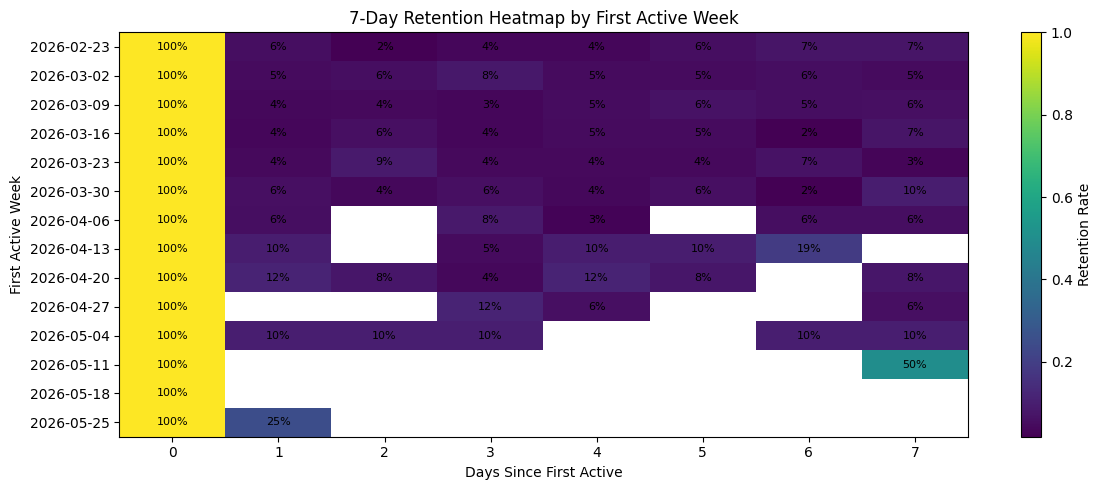

In [17]:
heatmap_data = weekly_cohort_matrix_7d.copy()

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(heatmap_data.values, aspect="auto")

ax.set_title("7-Day Retention Heatmap by First Active Week")
ax.set_xlabel("Days Since First Active")
ax.set_ylabel("First Active Week")

ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index.strftime("%Y-%m-%d"))

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.0%}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Retention Rate")

plt.tight_layout()
plt.show()

## Key Findings

1. Using an exact-day retention definition, Day 0 retention is 100% by construction, while adjusted Day 1, Day 3, and Day 7 retention are 4.8%, 5.5%, and 5.9%, respectively.

2. Short-term re-engagement appears low: only about 5–6% of users return on the selected days after their first activity. This indicates that many users interact with the product once but do not build a recurring usage habit within the first week.

3. The observation-window-adjusted retention rates are very close to the unadjusted rates, suggesting that most users in the dataset had enough follow-up time for Day 1, Day 3, and Day 7 retention measurement.

4. Weekly cohort retention provides a more stable view than daily cohort retention. The heatmap shows some variation across first-active weeks, but most post-Day-0 retention rates remain in the single digits.

5. From a product analytics perspective, this retention pattern suggests that the next investigation should focus on early lifecycle engagement, such as onboarding experience, first-session value, follow-up emails or notifications, and whether users have a clear reason to return after their initial interaction.